In [20]:
!pip install geopandas rasterio shapely scikit-learn seaborn torchvision -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point, box

import rasterio
from rasterio.transform import rowcol

from PIL import Image
from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [21]:
from google.colab import drive
drive.mount('/content/drive')

BASE       = '/content/drive/MyDrive/iitg'

ncr        = gpd.read_file(f'{BASE}/delhi_ncr_region.geojson')
airshed    = gpd.read_file(f'{BASE}/delhi_airshed.geojson')
RGB_FOLDER = f'{BASE}/rgb'
TIF_PATH   = f'{BASE}/worldcover_bbox_delhi_ncr_2021.tif'
all_images = [f for f in os.listdir(RGB_FOLDER) if f.endswith('.png')]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


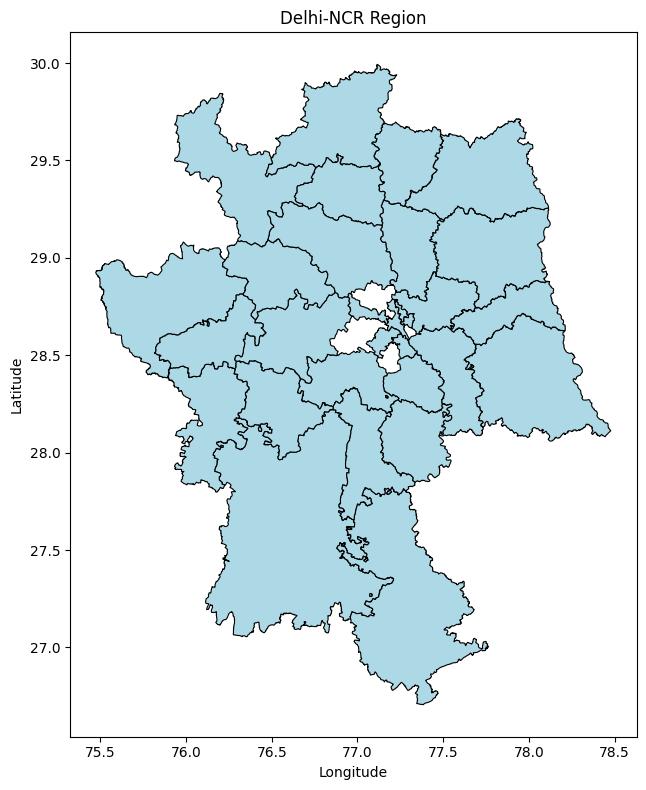

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))

ncr.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)

ax.set_title('Delhi-NCR Region')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

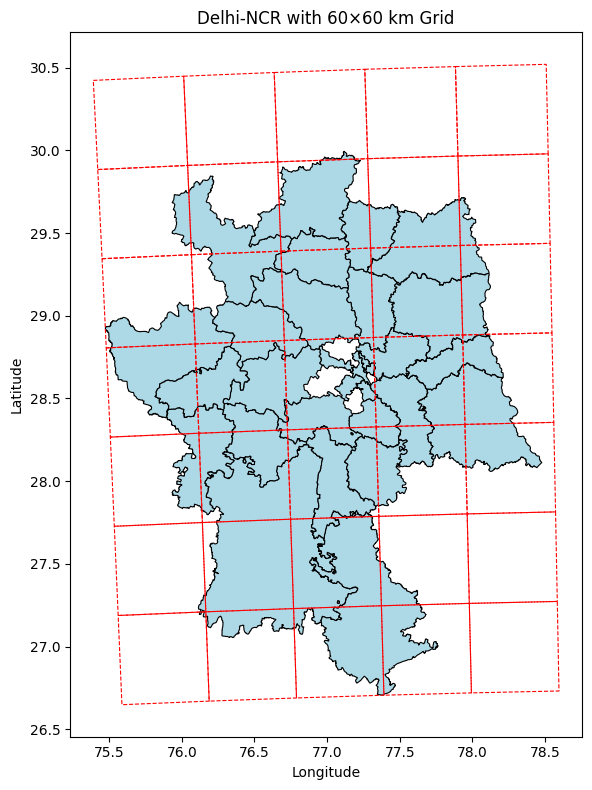

In [23]:
ncr_proj = ncr.to_crs(epsg=32644)
minx, miny, maxx, maxy = ncr_proj.total_bounds

cell_size  = 60000
grid_cells = []

x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))
        y += cell_size
    x += cell_size

grid      = gpd.GeoDataFrame(geometry=grid_cells, crs='EPSG:32644')
grid_4326 = grid.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(8, 8))
ncr.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)
grid_4326.boundary.plot(ax=ax, color='red', linewidth=0.8, linestyle='--')

ax.set_title('Delhi-NCR with 60×60 km Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

In [24]:
ncr_union = ncr.union_all()

records = []
for fname in all_images:
    # Step 1: Remove .png
    name = fname.replace('.png', '')
    # Step 2: Remove anything like " (1)" or " (2)"
    name = name.split(' ')[0]
    # Step 3: Now split by _ safely
    parts = name.split('_')
    lat   = float(parts[0])
    lon   = float(parts[1])
    records.append({'filename': fname, 'lat': lat, 'lon': lon})

df       = pd.DataFrame(records)
geometry = [Point(row['lon'], row['lat']) for _, row in df.iterrows()]
gdf      = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

df_filtered = gdf[gdf.geometry.within(ncr_union)].reset_index(drop=True)

print(f"Before filtering : {len(all_images)}")
print(f"After filtering  : {len(df_filtered)}")



Before filtering : 9229
After filtering  : 8027


Valid patches extracted : 8027


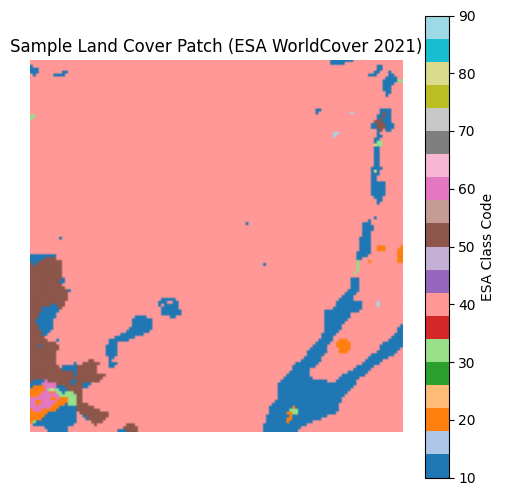

In [25]:
patch_size = 128
half       = patch_size // 2

with rasterio.open(TIF_PATH) as src:
    patches = []
    for _, row in df_filtered.iterrows():
        py, px = rowcol(src.transform, row['lon'], row['lat'])
        window = rasterio.windows.Window(px - half, py - half, patch_size, patch_size)
        patch  = src.read(1, window=window)
        if patch.shape == (128, 128):
            patches.append(patch)
        else:
            patches.append(None)

df_filtered['patch'] = patches
df_filtered = df_filtered[df_filtered['patch'].notnull()].reset_index(drop=True)
print(f"Valid patches extracted : {len(df_filtered)}")

# find the patch with the most unique land cover classes
best_idx = 0
best_count = 0
for i in range(len(df_filtered)):
    unique_classes = len(np.unique(df_filtered['patch'].iloc[i]))
    if unique_classes > best_count:
        best_count = unique_classes
        best_idx = i

plt.figure(figsize=(6, 6))
plt.imshow(df_filtered['patch'].iloc[best_idx], cmap='tab20')
plt.title('Sample Land Cover Patch (ESA WorldCover 2021)')
plt.colorbar(label='ESA Class Code')
plt.axis('off')
plt.show()

In [26]:
def get_mode(patch):
    values, counts = np.unique(patch, return_counts=True)
    return values[np.argmax(counts)]

df_filtered['raw_label'] = df_filtered['patch'].apply(get_mode)
print(df_filtered[['filename', 'raw_label']].head(10))
print("\nDominant class distribution:")
print(df_filtered['raw_label'].value_counts())

              filename  raw_label
0  28.8591_77.6234.png         40
1  28.8767_77.1943.png         40
2  28.8591_77.6146.png         40
3  28.8591_77.3910.png         40
4  28.8767_77.5821.png         40
5  28.8943_77.6322.png         40
6  28.8855_77.5058.png         40
7  28.8943_77.2146.png         40
8  28.8178_77.6058.png         40
9  28.8442_77.2734.png         40

Dominant class distribution:
raw_label
40    5480
50    1783
10     341
20     248
30     166
80       7
90       2
Name: count, dtype: int64


              filename  raw_label     label
0  28.8591_77.6234.png         40  Cropland
1  28.8767_77.1943.png         40  Cropland
2  28.8591_77.6146.png         40  Cropland
3  28.8591_77.3910.png         40  Cropland
4  28.8767_77.5821.png         40  Cropland
5  28.8943_77.6322.png         40  Cropland
6  28.8855_77.5058.png         40  Cropland
7  28.8943_77.2146.png         40  Cropland
8  28.8178_77.6058.png         40  Cropland
9  28.8442_77.2734.png         40  Cropland


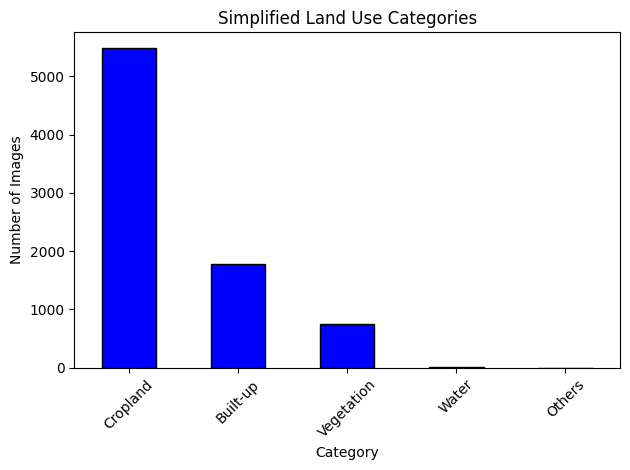

In [27]:
esa_map = {
    10 : 'Vegetation',
    20 : 'Vegetation',
    30 : 'Vegetation',
    40 : 'Cropland',
    50 : 'Built-up',
    60 : 'Others',
    70 : 'Others',
    80 : 'Water',
    90 : 'Others',
    95 : 'Vegetation',
    100: 'Others'
}

df_filtered['label'] = df_filtered['raw_label'].map(esa_map).fillna('Others')

# Show mapping worked — raw code vs simplified label
print(df_filtered[['filename', 'raw_label', 'label']].head(10))

# Visual bar chart of simplified categories
df_filtered['label'].value_counts().plot(kind='bar', color='blue', edgecolor='black')
plt.title('Simplified Land Use Categories')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Train size : 4816
Test size  : 3211


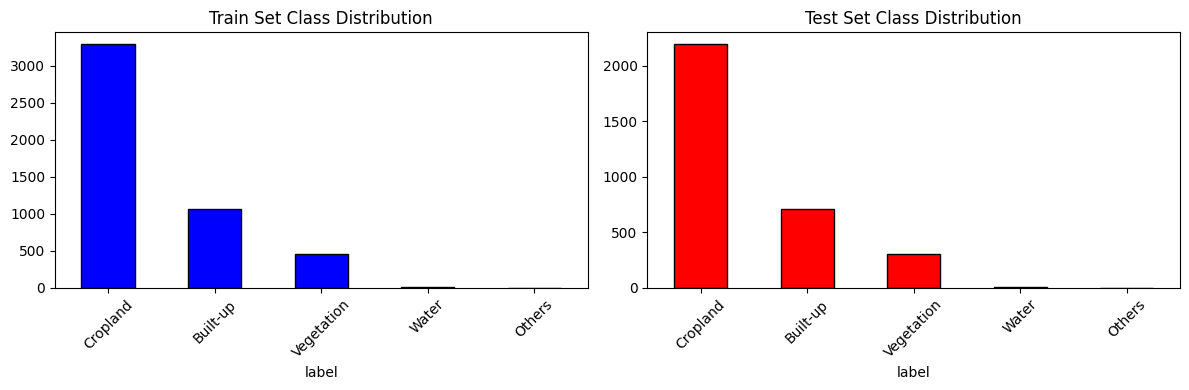

In [28]:
train_df, test_df = train_test_split(
    df_filtered, test_size=0.4, random_state=42, stratify=df_filtered['label']
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train size : {len(train_df)}")
print(f"Test size  : {len(test_df)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color='blue', edgecolor='black')
axes[0].set_title('Train Set Class Distribution')
axes[0].tick_params(axis='x', rotation=45)

test_df['label'].value_counts().plot(kind='bar', ax=axes[1], color='red', edgecolor='black')
axes[1].set_title('Test Set Class Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [31]:
RGB_FOLDER = '/content/drive/MyDrive/iitg/rgb'
classes   = sorted(df_filtered['label'].unique())
label2idx = {c: i for i, c in enumerate(classes)}

#Dataset class — tells PyTorch how to load one image and its label
class LandUseDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        # Open the RGB image
        image = Image.open(os.path.join(RGB_FOLDER, row['filename'])).convert('RGB')
        if self.transform:
            image = self.transform(image)
        # Return image and its numeric label
        return image, label2idx[row['label']]

#Transform — resize, convert to tensor, normalize
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

#Create data loaders — loads images
train_loader = DataLoader(LandUseDataset(train_df, transform), batch_size=32, shuffle=True)
test_loader  = DataLoader(LandUseDataset(test_df,  transform), batch_size=32, shuffle=False)

#Load ResNet18 — a pretrained CNN, replace last layer for our classes
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model    = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, len(classes))
model    = model.to(device)

#Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#Training loop — 10 epochs
for epoch in range(10):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()               # Clear old gradients
        loss = criterion(model(images), labels)  # Calculate loss
        loss.backward()                     # Backpropagate
        optimizer.step()                    # Update weights
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/10 — Loss: {avg_loss:.4f}")

print(f"\n Training complete! Device used: {device}")
print(f"Classes: {classes}")


Epoch 1/10 — Loss: 0.3567
Epoch 2/10 — Loss: 0.2811
Epoch 3/10 — Loss: 0.2367
Epoch 4/10 — Loss: 0.1934
Epoch 5/10 — Loss: 0.1522
Epoch 6/10 — Loss: 0.1306
Epoch 7/10 — Loss: 0.0806
Epoch 8/10 — Loss: 0.0630
Epoch 9/10 — Loss: 0.0938
Epoch 10/10 — Loss: 0.0746

 Training complete! Device used: cuda
Classes: ['Built-up', 'Cropland', 'Others', 'Vegetation', 'Water']


In [29]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images      = images.to(device)
        _, predicted = model(images).max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(f"Accuracy : {accuracy_score(all_labels, all_preds)*100:.2f}%")
print(f"F1 Score : {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(classification_report(all_labels, all_preds, target_names=classes))

Accuracy : 89.16%
F1 Score : 0.8800
              precision    recall  f1-score   support

    Built-up       0.96      0.78      0.86       713
    Cropland       0.88      1.00      0.93      2192
      Others       0.00      0.00      0.00         1
  Vegetation       0.85      0.40      0.55       302
       Water       0.00      0.00      0.00         3

    accuracy                           0.89      3211
   macro avg       0.54      0.44      0.47      3211
weighted avg       0.89      0.89      0.88      3211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


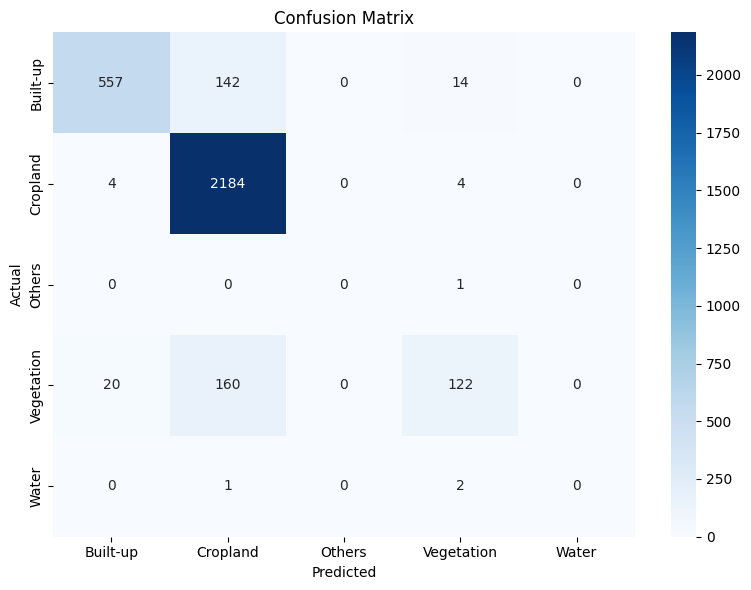

In [32]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation

The model performs best on **Cropland** as it is the dominant class in Delhi NCR.

**Built-up** areas are occasionally confused with Others due to similar spectral features.

Class imbalance causes lower F1 scores on minority classes like **Water** and **Vegetation**.
